# Importing necessary libraries


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import scipy.io as sio
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from scipy.signal import hilbert
from tensorflow.keras.layers import Lambda
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.utils import to_categorical
import seaborn as sns

# Data Augmentation

In [3]:
# Importing the MAT Files only
# The following directory contains all the raw audio files obtained from CWRU Bearing Dataset
# The files are names as: SR_XX_ZZ_FFFF.mat, where SR = Sampling Rate, XX = DE (Drive end) / FE (Fan end), ZZ = IR (Inner Race) / OR (Outer Race) / BR (Ball Race), FFFF - Actual File Name
mat_files_directory = "/content/drive/MyDrive/FYP Phase II/MAT Files"

In [ ]:
# Find the count of files with OR, BR, IR, and Normal in their file names
# Initialize counters
or_count = 0
ir_count = 0
br_count = 0
normal_count = 0
# Iterate through files in the directory
for filename in os.listdir(mat_files_directory):
    if filename.endswith(".mat"):  # Consider only .mat files
        if "OR" in filename:
            or_count += 1
        if "IR" in filename:
            ir_count += 1
        if "BR" in filename:
            br_count += 1
        if "Normal" in filename:
            normal_count += 1

# Print the counts
print("Number of files with 'OR':", or_count)
print("Number of files with 'IR':", ir_count)
print("Number of files with 'BR':", br_count)
print("Number of files with 'Normal':", normal_count)

Number of files with 'OR': 77
Number of files with 'IR': 40
Number of files with 'BR': 40
Number of files with 'Normal': 4


The actual data is unbalanced as seen.

In [ ]:
# Performing data augmentation

import os
import numpy as np
import scipy.io as sio
import librosa

# === Load Signal from .mat File ===
def load_mat_signal(file_path):
    mat_data = sio.loadmat(file_path)
    for key in mat_data:
        if "DE_time" in key:
            return mat_data[key].squeeze(), key, mat_data
    raise ValueError(f"No DE_time signal found in {file_path}")

# === Augmentation Functions ===
def add_noise(signal, noise_level=0.005):
    noise = np.random.randn(len(signal))
    return signal + noise_level * noise

def time_shift(signal, shift_max=500):
    shift = np.random.randint(-shift_max, shift_max)
    return np.roll(signal, shift)

def scale_amplitude(signal, factor_range=(0.8, 1.2)):
    return signal * np.random.uniform(*factor_range)

def time_stretch(signal, rate=1.1):
    return librosa.effects.time_stretch(signal.astype(np.float32), rate)

# === Optional: Convert to MFCC ===
SR = 16000
N_MFCC = 39
def convert_to_mfcc(signal, sr=SR, n_mfcc=N_MFCC):
    return librosa.feature.mfcc(y=signal.astype(np.float32), sr=sr, n_mfcc=n_mfcc)

# === Augment and Save Helper ===
def augment_and_save(input_dir, output_dir, target_total):
    os.makedirs(output_dir, exist_ok=True)

    file_list = [f for f in os.listdir(input_dir) if f.endswith('.mat')]
    current_total = len(file_list)
    print(f"[{os.path.basename(input_dir)}] Original files: {current_total}, Target: {target_total}")

    if current_total >= target_total:
        # Just copy files
        for file_name in file_list:
            src = os.path.join(input_dir, file_name)
            dst = os.path.join(output_dir, file_name)
            data = sio.loadmat(src)
            sio.savemat(dst, data)
        print(f"✅ Copied {current_total} files to {output_dir}")
        return

    # Calculate how many augmentations per file
    aug_needed = target_total - current_total
    aug_per_file = int(np.ceil(aug_needed / current_total))

    count = 0
    for file_name in file_list:
        input_path = os.path.join(input_dir, file_name)
        try:
            signal, key, original_data = load_mat_signal(input_path)

            # Save original
            base_name = os.path.splitext(file_name)[0]
            orig_out = os.path.join(output_dir, base_name + '.mat')
            sio.savemat(orig_out, original_data)
            count += 1

            # Augment and save
            for i in range(aug_per_file):
                aug_signal = signal.copy()

                if np.random.rand() < 0.7:
                    aug_signal = add_noise(aug_signal)
                if np.random.rand() < 0.5:
                    aug_signal = time_shift(aug_signal)
                if np.random.rand() < 0.5:
                    aug_signal = scale_amplitude(aug_signal)
                if np.random.rand() < 0.3:
                    try:
                        aug_signal = time_stretch(aug_signal)
                    except:
                        pass  # Skip if too short

                aug_data = original_data.copy()
                aug_data[key] = aug_signal

                aug_name = f"{base_name}_aug_{i+1:02d}.mat"
                aug_path = os.path.join(output_dir, aug_name)
                sio.savemat(aug_path, aug_data)
                count += 1

                if count >= target_total:
                    break
            if count >= target_total:
                break

        except ValueError as e:
            print(f"⚠️ {e}")

    print(f"✅ Saved {count} files to {output_dir} (balanced)")

# === Master Driver ===
class_configs = {
    "Normal": {"input_dir": "/content/drive/MyDrive/FYP Phase II/Original Data/Normal", "target_total": 77},
    "OR":     {"input_dir": "/content/drive/MyDrive/FYP Phase II/Original Data/Outer Race Fault",     "target_total": 77},
    "IR":     {"input_dir": "/content/drive/MyDrive/FYP Phase II/Original Data/Inner Race Fault",     "target_total": 77},
    "BR":     {"input_dir": "/content/drive/MyDrive/FYP Phase II/Original Data/Ball Fault",     "target_total": 77},
}

for class_name, config in class_configs.items():
    print(f"\n📦 Processing class: {class_name}")
    output_dir = f"dataset/{class_name}"
    augment_and_save(config["input_dir"], output_dir, config["target_total"])



📦 Processing class: Normal
[Normal] Original files: 4, Target: 77
✅ Saved 77 files to dataset/Normal (balanced)

📦 Processing class: OR
[Outer Race Fault] Original files: 77, Target: 77
✅ Copied 77 files to dataset/OR

📦 Processing class: IR
[Inner Race Fault] Original files: 40, Target: 77
✅ Saved 78 files to dataset/IR (balanced)

📦 Processing class: BR
[Ball Fault] Original files: 40, Target: 77
✅ Saved 78 files to dataset/BR (balanced)


Data Augmentation created a balance in the data as seen.

In [ ]:
# Converting the RAW audio signals to MFCC
SR = 16000
N_MFCC = 39
def convert_to_mfcc(signal, sr=SR, n_mfcc=N_MFCC):
    return librosa.feature.mfcc(y=signal.astype(np.float32), sr=sr, n_mfcc=n_mfcc)
# === Signal Loader ===
def load_signal_from_mat(file_path):
    mat_data = sio.loadmat(file_path)
    for key in mat_data:
        if "DE_time" in key:
            return mat_data[key].squeeze()
    raise ValueError(f"No DE_time key found in {file_path}")
# === Convert All Files ===
def convert_class_to_mfcc(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    file_list = [f for f in os.listdir(input_dir) if f.endswith(".mat")]

    for file_name in file_list:
        file_path = os.path.join(input_dir, file_name)
        try:
            signal = load_signal_from_mat(file_path)
            mfcc = convert_to_mfcc(signal)
            save_path = os.path.join(output_dir, os.path.splitext(file_name)[0] + ".npy")
            np.save(save_path, mfcc)
        except Exception as e:
            print(f"⚠️ Failed on {file_name}: {e}")

    print(f"✅ Converted {len(file_list)} files in {input_dir} → {output_dir}")

# === Master Driver ===
class_names = ["Normal", "OR", "IR", "BR"]

for cls in class_names:
    input_dir = f"/content/drive/MyDrive/FYP Phase II/dataset/{cls}"
    output_dir = f"/content/drive/MyDrive/FYP Phase II/mfcc_data/{cls}"
    print(f"\n🎧 Converting class {cls} to MFCCs...")
    convert_class_to_mfcc(input_dir, output_dir)

# Model Training

In [4]:
DATASET_PATH = "/content/drive/MyDrive/FYP Phase II/DATASET_FINAL"

In [5]:
FIXED_MFCC_SHAPE = (39, 1280)  # (num_mfcc, time_steps)
# Function to load and pad .npy files
def load_data(dataset_path):
    X, Y = [], []
    for file in os.listdir(dataset_path):
        if file.endswith('.npy'):
            file_path = os.path.join(dataset_path, file)
            mfcc_data = np.load(file_path)

            # Pad or truncate to fixed shape
            pad_width = [(0, max(0, FIXED_MFCC_SHAPE[0] - mfcc_data.shape[0])),
                         (0, max(0, FIXED_MFCC_SHAPE[1] - mfcc_data.shape[1]))]
            mfcc_padded = np.pad(mfcc_data, pad_width, mode='constant')[:FIXED_MFCC_SHAPE[0], :FIXED_MFCC_SHAPE[1]]

            # Assign label
            if file.startswith('Normal_'):
                label = 'Normal'
            else:
                label = file.split('_')[3]

            X.append(mfcc_padded)
            Y.append(label)

    return np.array(X), np.array(Y)

# Load dataset
X, Y = load_data(DATASET_PATH)
# Convert labels to numerical format
label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(Y)  # Convert text labels to integers

# Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Reshape for CNN input (adding channel dimension)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [13]:
# Model Development

def build_cnn_rnn(input_shape, num_classes):
    model = keras.Sequential([
        # CNN Feature Extraction
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # 🔹 Use Global Average Pooling
        layers.GlobalAveragePooling2D(),

        # 🔹 Reshape for RNN (Maintain Temporal Structure)
        layers.Reshape((-1, 128)),

        # 🔹 Use GRU Instead of LSTM for Faster Training
        layers.GRU(64, return_sequences=True),
        layers.GRU(64, return_sequences=False),
        layers.Reshape((1, 64)),
        # 🔹 Small Conv1D Layer to Refine RNN Output
        layers.Conv1D(64, 3, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),

        # Fully Connected Layers
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


# Model Training
input_shape = (FIXED_MFCC_SHAPE[0], FIXED_MFCC_SHAPE[1], 1)
num_classes = len(np.unique(Y))

model = build_cnn_rnn(input_shape, num_classes)
optimizer = keras.optimizers.Adam(learning_rate=0.0003, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train, Y_train, epochs=100, batch_size=16, validation_data=(X_test, Y_test))


# Evaluate Model
test_loss, test_acc = model.evaluate(X_test, Y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Save Model
# model.save("/content/drive/MyDrive/motor_fault_cnn_rnn_1.h5")

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.3335 - loss: 1.3757 - val_accuracy: 0.5806 - val_loss: 1.3107
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4685 - loss: 1.2954 - val_accuracy: 0.5161 - val_loss: 1.1756
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5271 - loss: 1.1344 - val_accuracy: 0.4839 - val_loss: 0.9927
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5226 - loss: 0.9464 - val_accuracy: 0.5000 - val_loss: 0.8751
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5272 - loss: 0.8389 - val_accuracy: 0.6774 - val_loss: 0.8102
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6114 - loss: 0.8233 - val_accuracy: 0.6452 - val_loss: 0.7545
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6330 - loss: 0.7702 - val_accuracy: 0.6129 - val_loss: 0.7577
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6510 - loss: 0.7308 - val_accuracy: 0.

# Model Evaluation

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Smooth the curves using Savitzky-Golay filter
def smooth_curve(data, window=11, poly=3):
    if len(data) < window:
        return data  # too short to smooth
    return savgol_filter(data, window_length=window, polyorder=poly)

# Extract history
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Apply smoothing
loss_smooth = smooth_curve(loss)
val_loss_smooth = smooth_curve(val_loss)
acc_smooth = smooth_curve(acc)
val_acc_smooth = smooth_curve(val_acc)

In [21]:
# Install Times New Roman font on Colab
!apt-get install -y fonts-times-new-roman

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package fonts-times-new-roman


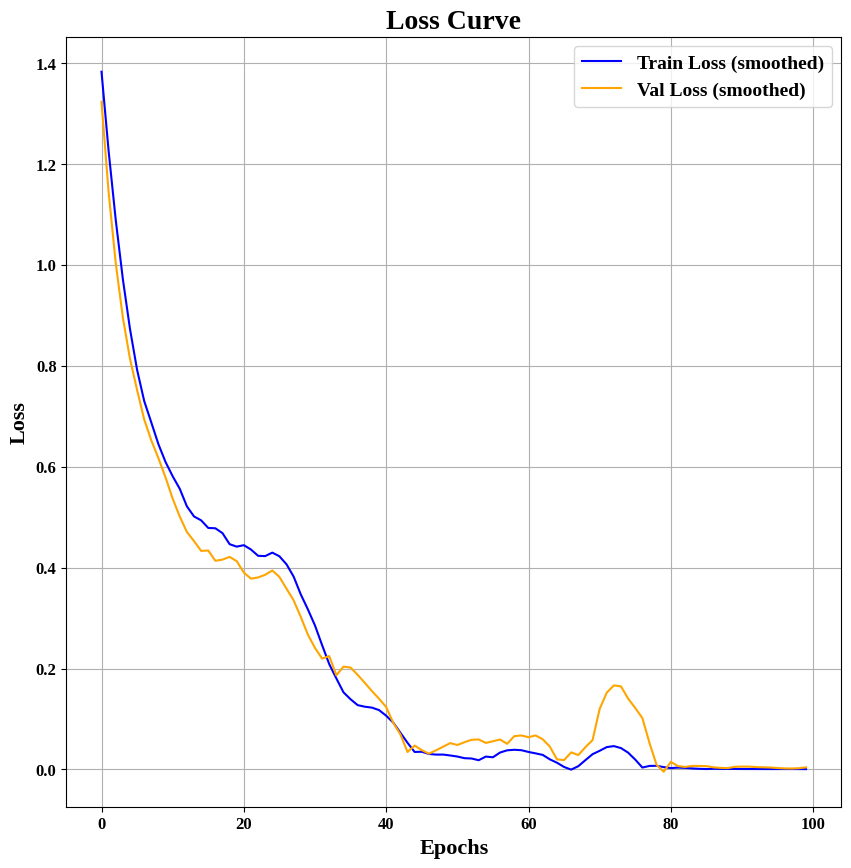

In [24]:
import matplotlib.pyplot as plt

# Set global font to Times New Roman and bold
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'Liberation Serif', 'serif']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Plotting
plt.figure(figsize=(10, 10))

# Loss Curve
plt.plot(loss_smooth, label='Train Loss (smoothed)', color='blue')
plt.plot(val_loss_smooth, label='Val Loss (smoothed)', color='orange')

plt.title('Loss Curve', fontsize=20, fontweight='bold')
plt.xlabel('Epochs', fontsize=16, fontweight='bold')
plt.ylabel('Loss', fontsize=16, fontweight='bold')
plt.legend(fontsize=14)
plt.grid(True)
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.show()


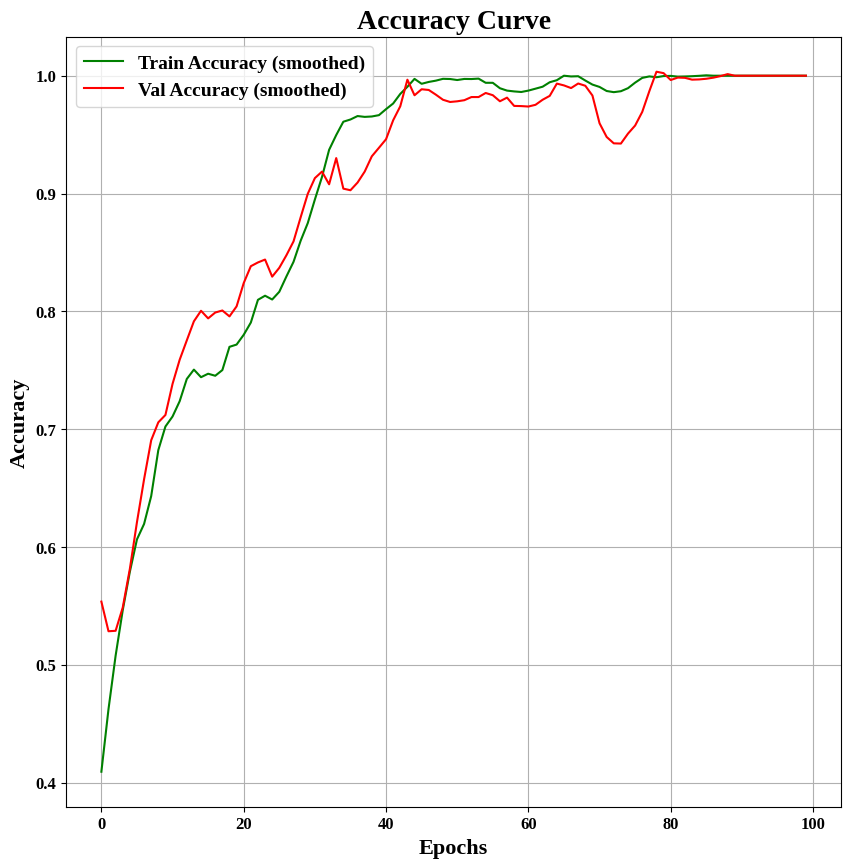

In [25]:
import matplotlib.pyplot as plt

# Set global font to Times New Roman and bold
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'Liberation Serif', 'serif']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Plotting
plt.figure(figsize=(10, 10))

# Accuracy Curve
plt.plot(acc_smooth, label='Train Accuracy (smoothed)', color='green')
plt.plot(val_acc_smooth, label='Val Accuracy (smoothed)', color='red')

plt.title('Accuracy Curve', fontsize=20, fontweight='bold')
plt.xlabel('Epochs', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=16, fontweight='bold')
plt.legend(fontsize=14)
plt.grid(True)
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step


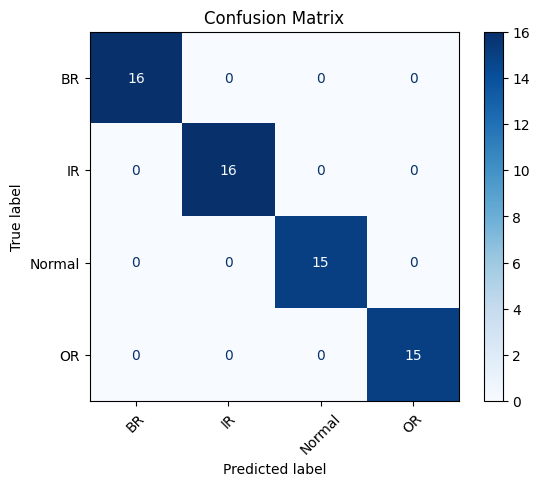

In [6]:
# Predict labels
model = tf.keras.models.load_model("/content/drive/MyDrive/motor_fault_cnn_rnn_1.h5")
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

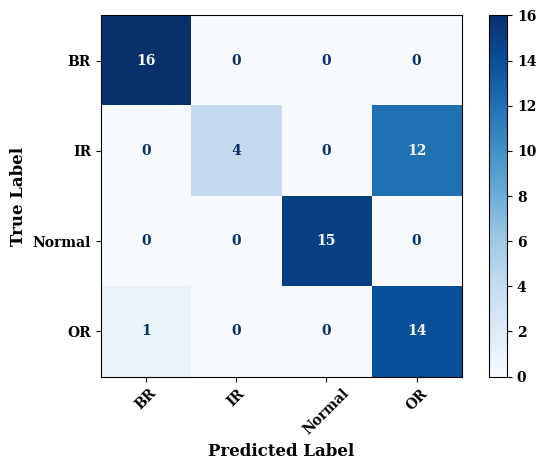

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import rcParams

# Set serif font and bold globally
rcParams['font.family'] = 'serif'
rcParams['font.weight'] = 'bold'
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.titleweight'] = 'bold'

# Generate and display the confusion matrix
cm = confusion_matrix(Y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)


# Bold and serif title
plt.xlabel('Predicted Label', fontweight='bold', fontsize=12, family='serif')
plt.ylabel('True Label', fontweight='bold', fontsize=12, family='serif')
plt.xticks(fontweight='bold', family='serif')
plt.yticks(fontweight='bold', family='serif')

plt.grid(False)  # optional
plt.tight_layout()
plt.show()


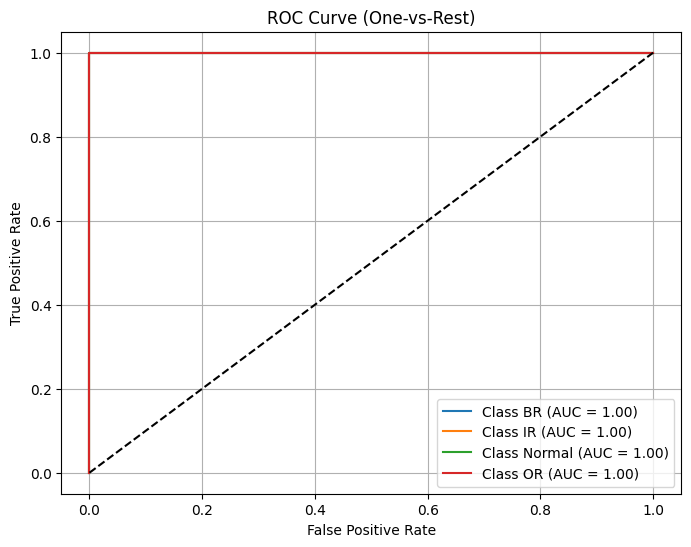

In [ ]:
# One-hot encode the true labels
Y_test_bin = label_binarize(Y_test, classes=np.arange(num_classes))
y_score = y_pred  # already softmax probabilities

# Plot ROC
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 39, 1280, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 640, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 19, 640, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 320, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 320, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 160, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 1, 64)          │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 528,206 (2.01 MB)

 Trainable params: 176,068 (687.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 352,138 (1.34 MB)

In [ ]:
import time
import numpy as np
import tensorflow as tf

# Load your trained model
model = tf.keras.models.load_model("/content/drive/MyDrive/motor_fault_cnn_rnn_1.h5")

# Generate a random input sample matching the model's input shape
sample_input = np.random.rand(1, 39, 1280, 1).astype(np.float32)

# Measure inference time over multiple runs
num_trials = 100
total_time = 0

for _ in range(num_trials):
    start_time = time.time()
    _ = model.predict(sample_input, verbose=0)  # Run inference
    end_time = time.time()
    total_time += (end_time - start_time)

# Calculate average latency per inference
average_latency = (total_time / num_trials) * 1000  # Convert to milliseconds

print(f"Average Inference Time: {average_latency:.4f} ms")
loss, acc = model.evaluate(X_test, Y_test, verbose=2)
print(f"Test Accuracy after weight approximation: {acc:.4f}")

Average Inference Time: 144.8926 ms
2/2 - 4s - 2s/step - accuracy: 1.0000 - loss: 0.0030
Test Accuracy after weight approximation: 1.0000


# Quantisation and Approximation


This code file doesn't contain the code for performing quantization and approximation

In [ ]:
model_f = tf.keras.models.load_model("/content/drive/MyDrive/motor_fault_cnn_rnn_pow2_approx.h5")
# Generate a random input sample matching the model's input shape
sample_input = np.random.rand(1, 39, 1280, 1).astype(np.float32)

# Measure inference time over multiple runs
num_trials = 100
total_time = 0

for _ in range(num_trials):
    start_time = time.time()
    _ = model_f.predict(sample_input, verbose=0)  # Run inference
    end_time = time.time()
    total_time += (end_time - start_time)

# Calculate average latency per inference
average_latency = (total_time / num_trials) * 1000  # Convert to milliseconds

print(f"Average Inference Time: {average_latency:.4f} ms")

loss, acc = model_f.evaluate(X_test, Y_test, verbose=2)
print(f"Test Accuracy after weight approximation: {acc:.4f}")

Average Inference Time: 139.9815 ms
2/2 - 3s - 1s/step - accuracy: 0.7903 - loss: 1.0999
Test Accuracy after weight approximation: 0.7903


# Evaluation on the final model

In [ ]:
model_f.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 39, 1280, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 640, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 19, 640, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 320, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 320, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 160, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 1, 64)          │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,070 (687.78 KB)

 Trainable params: 176,068 (687.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [13]:
# Predict labels
model_f = tf.keras.models.load_model("/content/drive/MyDrive/motor_fault_cnn_rnn_pow2_approx.h5")
y_pred = model_f.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step


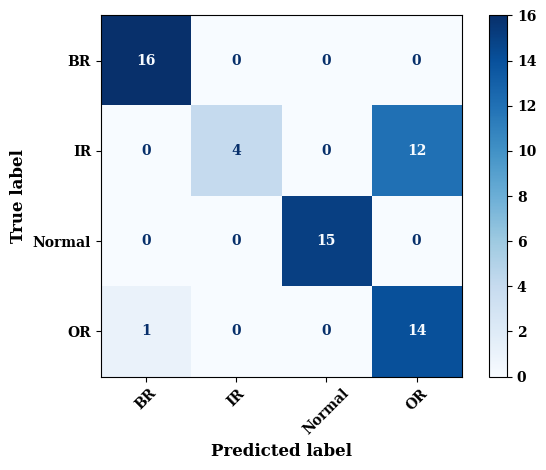

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import rcParams

# Set serif font and bold globally
rcParams['font.family'] = 'serif'
rcParams['font.weight'] = 'bold'
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.titleweight'] = 'bold'

# Generate and display the confusion matrix
cm = confusion_matrix(Y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)

# Bold and serif title
plt.xlabel('Predicted label', fontweight='bold', fontsize=12, family='serif')
plt.ylabel('True label', fontweight='bold', fontsize=12, family='serif')
plt.xticks(fontweight='bold', family='serif')
plt.yticks(fontweight='bold', family='serif')

plt.grid(False)  # optional
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix
cm = confusion_matrix(Y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

# Evaluation on the best possible embeddabale model

In [9]:
# Load the TFLite model and allocate tensors.
interpreter = tf.lite.Interpreter(model_path="/content/drive/MyDrive/motor_fault_quantized_fp16.tflite")
interpreter.allocate_tensors()

# Get input and output tensors.
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test the model on random input data.
input_shape = input_details[0]['shape']
input_data = np.array(np.random.random_sample(input_shape), dtype=np.float32)
interpreter.set_tensor(input_details[0]['index'], input_data)

interpreter.invoke()

# The function `get_tensor()` returns an array of the output data.
output_data = interpreter.get_tensor(output_details[0]['index'])
print(output_data)

[[0.27939382 0.16198531 0.07165106 0.4869698 ]]


In [10]:
correct = 0
total = len(X_test)

for i in range(total):
    input_tensor = X_test[i:i+1].astype(np.float32)  # or np.uint8 if you used int8 quant

    # Set the input tensor
    interpreter.set_tensor(input_details[0]['index'], input_tensor)
    interpreter.invoke()

    # Get output
    output = interpreter.get_tensor(output_details[0]['index'])
    pred_label = np.argmax(output)

    if pred_label == Y_test[i]:
        correct += 1

accuracy = correct / total
print(f"TFLite Quantized Model Accuracy: {accuracy:.4f}")

TFLite Quantized Model Accuracy: 0.9839


In [11]:
y_pred_tflite = []
for i in range(len(X_test)):
    input_tensor = X_test[i:i+1].astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_tensor)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    pred_label = np.argmax(output)
    y_pred_tflite.append(pred_label)

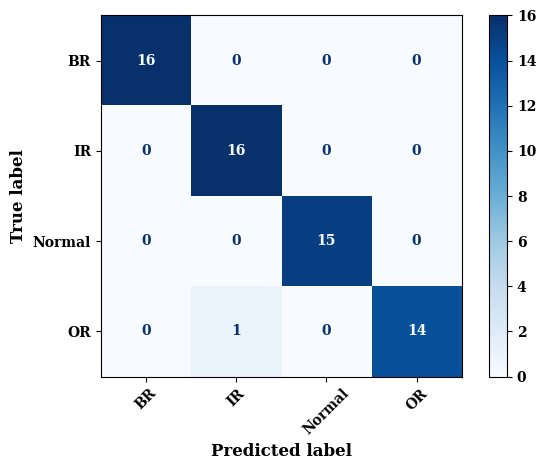

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import rcParams

# Set serif font and bold globally
rcParams['font.family'] = 'serif'
rcParams['font.weight'] = 'bold'
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.titleweight'] = 'bold'

# Generate and display the confusion matrix
cm_tflite = confusion_matrix(Y_test, y_pred_tflite)
disp_tflite = ConfusionMatrixDisplay(confusion_matrix=cm_tflite, display_labels=label_encoder.classes_)
disp_tflite.plot(cmap='Blues', xticks_rotation=45)

# Bold and serif title
plt.xlabel('Predicted label', fontweight='bold', fontsize=12, family='serif')
plt.ylabel('True label', fontweight='bold', fontsize=12, family='serif')
plt.xticks(fontweight='bold', family='serif')
plt.yticks(fontweight='bold', family='serif')

plt.grid(False)  # optional
plt.tight_layout()
plt.show()

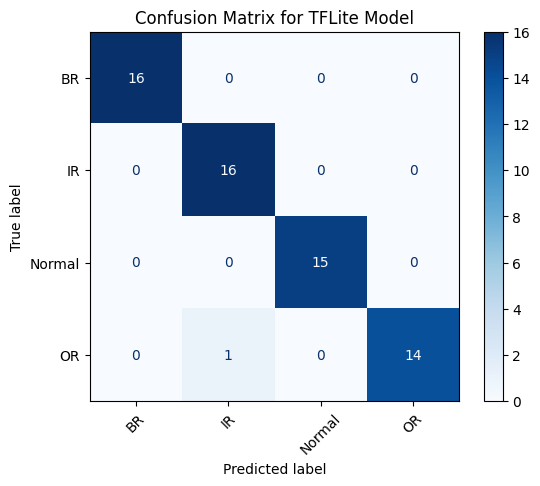

In [ ]:
cm_tflite = confusion_matrix(Y_test, y_pred_tflite)
disp_tflite = ConfusionMatrixDisplay(confusion_matrix=cm_tflite, display_labels=label_encoder.classes_)
disp_tflite.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix for TFLite Model')
plt.show()